In [1]:
using MLJ
using MLJFlux                  # interfaz para modelos Flux
using MLJScikitLearnInterface  # interfaz para SVM (scikit-learn wrapper)
using NearestNeighborModels    # interfaz para KNN
using Random
using LIBSVM
using Pkg
using MLJModelInterface
Pkg.precompile()


Precompiling project...
           ✗ PyCall
           ✗ ScikitLearn
  0 dependencies successfully precompiled in 26 seconds. 613 already precompiled.



Base.Precompilation.PkgPrecompileError: The following 2 direct dependencies failed to precompile:

PyCall 

Failed to precompile PyCall [438e738f-606a-5dbb-bf0a-cddfbfd45ab0] to "C:\\Users\\Usuario\\.julia\\compiled\\v1.11\\PyCall\\jl_5C60.tmp".
[91m[1mERROR: [22m[39mLoadError: PyCall not properly installed. Please run Pkg.build("PyCall")
Stacktrace:
 [1] [0m[1merror[22m[0m[1m([22m[90ms[39m::[0mString[0m[1m)[22m
[90m   @[39m [90mBase[39m [90m.\[39m[90m[4merror.jl:35[24m[39m
 [2] top-level scope
[90m   @[39m [90mC:\Users\Usuario\.julia\packages\PyCall\1gn3u\src\[39m[90m[4mstartup.jl:44[24m[39m
 [3] [0m[1minclude[22m[0m[1m([22m[90mmod[39m::[0mModule, [90m_path[39m::[0mString[0m[1m)[22m
[90m   @[39m [90mBase[39m [90m.\[39m[90m[4mBase.jl:557[24m[39m
 [4] [0m[1minclude[22m[0m[1m([22m[90mx[39m::[0mString[0m[1m)[22m
[90m   @[39m [35mPyCall[39m [90mC:\Users\Usuario\.julia\packages\PyCall\1gn3u\src\[39m[90m[4mPyCall.

In [2]:
using MLJ
using MLJFlux
using MLJScikitLearnInterface
using NearestNeighborModels
using Random
using LIBSVM
using Pkg
using MLJModelInterface
using MLJBase
using CategoricalArrays
using Statistics
using DataFrames
using CSV
using Tables
using Plots

import MLJBase: fit!, transform, machine, predict, predict_mode

In [3]:
include("P2.jl")
include("PEARSON.jl")
include("SPEARMAN.jl")
include("ANOVA.jl")
include("KENDALL_TAU.jl")
include("RFE.jl")
include("MUTUALINFORMATION.jl")

output_scitype (generic function with 80 methods)

# 1. Preparación de los datos

## 1.1. Carga y unificación de datos

In [4]:
unifyDataset("./DatosPractica", "./dataset.csv") # Se leen todos los datos del árbol de carpetas y se guardan en un único csv

df = CSV.read("./dataset.csv", DataFrame) # Lectura de ese mismo csv

subjects, dataset, targets = separateDataframe(df)

println("Numero de variables: $(length(dataset[1,:]))")
println("Numero de instancias: $(length(dataset[:,1]))")
println("Número de sujetos: $(length(unique(subjects)))")
println("Número de clases de salida: $(length(unique(targets)))")


Numero de variables: 561
Numero de instancias: 10299
Número de sujetos: 30
Número de clases de salida: 6


## 1.2. Análisis de valores ausentes

In [5]:
missings_per_variable = sum(ismissing.(x) for x in eachcol(dataset))

# TODO: Transformar a heatmap o algo 
for col in 1:length(dataset[1,:])
    println("$(names(dataset)[col]): $(round((missings_per_variable[col] * 100)/(length(dataset[1,:])), sigdigits = 5))%")
end

missingPercentage = (sum(missings_per_variable)*100)/(length(dataset[1,:])*length(dataset[:,1]))
println("Porcentaje de valores faltantes: $(round(missingPercentage, sigdigits = 5))%")

tBodyAcc-mean()-X: 0.71301%
tBodyAcc-mean()-Y: 0.71301%
tBodyAcc-mean()-Z: 0.89127%
tBodyAcc-std()-X: 0.89127%
tBodyAcc-std()-Y: 0.53476%
tBodyAcc-std()-Z: 0.89127%
tBodyAcc-mad()-X: 0.89127%
tBodyAcc-mad()-Y: 0.53476%
tBodyAcc-mad()-Z: 0.53476%
tBodyAcc-max()-X: 1.0695%
tBodyAcc-max()-Y: 0.89127%
tBodyAcc-max()-Z: 0.71301%
tBodyAcc-min()-X: 1.0695%
tBodyAcc-min()-Y: 1.0695%
tBodyAcc-min()-Z: 0.89127%
tBodyAcc-sma(): 0.89127%
tBodyAcc-energy()-X: 0.71301%
tBodyAcc-energy()-Y: 1.0695%
tBodyAcc-energy()-Z: 1.0695%
tBodyAcc-iqr()-X: 0.53476%
tBodyAcc-iqr()-Y: 1.2478%
tBodyAcc-iqr()-Z: 1.6043%
tBodyAcc-entropy()-X: 1.2478%
tBodyAcc-entropy()-Y: 1.2478%
tBodyAcc-entropy()-Z: 1.0695%
tBodyAcc-arCoeff()-X,1: 0.89127%
tBodyAcc-arCoeff()-X,2: 1.9608%
tBodyAcc-arCoeff()-X,3: 0.71301%
tBodyAcc-arCoeff()-X,4: 1.426%
tBodyAcc-arCoeff()-Y,1: 0.71301%
tBodyAcc-arCoeff()-Y,2: 0.71301%
tBodyAcc-arCoeff()-Y,3: 1.0695%
tBodyAcc-arCoeff()-Y,4: 0.89127%
tBodyAcc-arCoeff()-Z,1: 1.0695%
tBodyAcc-arCoeff()-Z,

## 1.3. Tratamiento de datos

In [6]:
# Eliminar missings del dataset
replaceWithMean!(dataset,subjects)

missings = sum(sum(ismissing.(x) for x in eachcol(dataset)))
missingPercentage = (missings*100)/(length(dataset[1,:])*length(dataset[:,1]))
println("Porcentaje de valores faltantes: $(round(missingPercentage, sigdigits = 5))%")

# Convertir el dataset a Array para trabajar más fácil con él
data = Array{Float32}(dataset)

Porcentaje de valores faltantes: 0.0%


10299×561 Matrix{Float32}:
 -0.361205   -0.268121     0.176896   …   0.508733  -0.496132  -0.506197
 -0.277066   -0.684097     0.346658       0.668284  -0.336641  -0.672685
 -0.239103   -0.0969044    0.148035       0.378792  -0.488443  -0.487057
 -0.166426   -0.119353     0.133035       0.272083  -0.534122  -0.397428
 -0.0832871   0.0102977   -0.516084       0.364277  -0.804865   0.144034
 -0.0662389   0.079229    -1.0        …   0.269545  -0.754285  -0.0974772
 -0.0417013   0.175102     0.0255518     -0.552939  -0.053539  -0.260424
  0.0139037   0.153296     0.0162429     -0.418368  -0.142549  -0.305884
  0.0190162  -0.00703736  -0.0283334      0.205759  -0.536104  -0.360736
  0.130461   -0.0549969   -0.131786      -0.766224   0.258457   0.03835
  ⋮                                   ⋱                         ⋮
  0.390494   -0.0186085   -0.0877924  …  -0.856499   0.197149   0.0107762
  0.396915   -0.0221819   -0.234221      -0.89164    0.149776  -0.0393991
  0.397628   -0.01348     -0.

In [7]:
encodedTargets = oneHotEncoding(targets)

10299×6 BitMatrix:
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 1  0  0  0  0  0
 0  1  0  0  0  0
 0  1  0  0  0  0
 1  0  0  0  0  0
 0  0  1  0  0  0
 ⋮              ⋮
 0  0  0  0  1  0
 0  0  1  0  0  0
 0  0  0  0  1  0
 0  0  1  0  0  0
 0  0  1  0  0  0
 0  0  0  1  0  0
 0  0  1  0  0  0
 0  0  1  0  0  0
 0  0  1  0  0  0

## 1.4. Partición Holdout

In [8]:
using Random

Random.seed!(104)

trainSubjectNumbers, testSubjectNumbers = holdOut(length(unique(subjects)), 0.1)

println("Test subjects: $testSubjectNumbers")

testIndices = findall(x-> x in testSubjectNumbers, subjects)

testData = data[testIndices,:]
testTargets = encodedTargets[testIndices,:]
testLabels = targets[testIndices,:]
testSubjects = subjects[testIndices]
println(unique(testSubjects))

println("Train subjects: $(sort(trainSubjectNumbers))")

trainIndices = findall(x-> x in trainSubjectNumbers, subjects)

trainData = data[trainIndices,:]
trainTargets = encodedTargets[trainIndices,:]
trainLabels = targets[trainIndices,:]
trainSubjects = subjects[trainIndices]
println(unique(trainSubjects))

Test subjects: [8, 24, 26]
[8, 24, 26]
Train subjects: [1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 27, 28, 29, 30]
[1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 27, 28, 29, 30]


## 1.5. Validación cruzada individual-wise

In [9]:
Random.seed!(104)

foldTrainData, foldTrainTargets, foldValData, foldValTargets = individualWiseFoldCrossValidation(trainSubjects, trainData, trainTargets, 5)

[3, 4, 1, 5, 4, 2, 3, 5, 3, 1, 2, 5, 4, 2, 2, 5, 1, 5, 2, 4, 4, 1, 3, 1, 2, 3, 1]
Individuos[3, 11, 18, 23, 27, 30]
[650, 651, 652, 653, 654, 655, 656, 657, 658, 659, 660, 661, 662, 663, 664, 665, 666, 667, 668, 669, 670, 671, 672, 673, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 684, 685, 686, 687, 688, 689, 690, 691, 692, 693, 694, 695, 696, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756, 757, 758, 759, 760, 761, 762, 763, 764, 765, 766, 767, 768, 769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 781, 782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826

(Any[Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.48435426 -0.00659472 … -0.60001034 -0.39974198; 0.48740166 -0.03021611 … 0.12563463 -0.09252271], Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.4445211 -0.031033007 … 0.13978489 -0.056221437; 0.49089193 0.015340722 … 0.1663592 -0.040976852], Float32[0.07103529 -0.015656183 … 0.32281327 0.010090114; 0.073728785 -0.14822575 … 0.25443897 0.4070857; … ; 0.4445211 -0.031033007 … 0.13978489 -0.056221437; 0.49089193 0.015340722 … 0.1663592 -0.040976852], Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.4445211 -0.031033007 … 0.13978489 -0.056221437; 0.49089193 0.015340722 … 0.1663592 -0.040976852], Float32[-0.36120534 -0.26812112 … -0.49613178 -0.5061973; -0.27706635 -0.6840966 … -0.3366412 -0.67268485; … ; 0.4445211 -0.031033007 … 0.13978489 -0.05

## 1.6. Normalización

In [10]:
using MLJModelInterface
using MLJBase
using Tables
using Statistics
import MLJModelInterface: fit, transform, input_scitype, target_scitype, output_scitype, predict

mutable struct MinMaxNormalizer <: Unsupervised
    mins::Vector{Float64}
    maxs::Vector{Float64}
end

MinMaxNormalizer() = MinMaxNormalizer(Float64[], Float64[])


function fit(model::MinMaxNormalizer, verbosity::Int, X)
    Xmat = Float64.(MLJBase.matrix(X))

    mins = mapslices(minimum, Xmat; dims=1) |> vec
    maxs = mapslices(maximum, Xmat; dims=1) |> vec

    fitresult = (mins, maxs)
    cache = nothing
    report = nothing

    return fitresult, cache, report
end

function transform(
    model::MinMaxNormalizer,
    fitresult,
    X
)
    mins, maxs = fitresult
    Xmat = MLJBase.matrix(X)

    Xscaled = (Xmat .- mins') ./ (maxs' .- mins')
    return MLJBase.table(Xscaled)
end

MLJModelInterface.input_scitype(::Type{MinMaxNormalizer}) = Table(Continuous)
MLJModelInterface.output_scitype(::Type{MinMaxNormalizer}) = Table(Continuous)


# 2. Modelos básicos y selección de atributos

In [11]:

# PCA = @load PCA pkg=MultivariateStats add=true
# ICA = @load ICA pkg=MultivariateStats
# LDA = @load LDA pkg=MultivariateStats

# KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
# SVC = @load ProbabilisticSVC pkg=LIBSVM verbosity=0
# NeuralNetworkClassifier = @load NeuralNetworkClassifier pkg=MLJFlux

# reducer=Dict(
#     "Sin Reducción" => nothing,
#     "PCA" => PCA(maxoutdim=50),
#     "ICA" => ICA(outdim=50, maxiter=500, tol=1, do_whiten=true),
#     "LDA" => LDA(outdim=50)
# )

# filter = Dict(
#     "Sin filtrado" => nothing,
#     "ANOVA" => ANOVAFilter(k=50),
#     "PEARSON" => PearsonFilter(k=50),
#     "SPEARMAN" => SpearmanFilter(k=50),
#     "KENDALLTAU" => KendallFilter(k=50),
#     "MI" => MutualInformation(k=50),
#     "RFE" => RFE(k=50)
# )

# models = Dict(
#     "KNN_1" => KNNClassifier(K=1),
#     "KNN_10" => KNNClassifier(K=10),
#     "KNN_20" => KNNClassifier(K=20),
#     "SVM_0.1" => SVC(cost=0.1),
#     "SVM_0.5" => SVC(cost=0.5),
#     "SVM_1" => SVC(cost=1.0),
#     "MLP_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
#     "MLP_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
#     "MLP_100-50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50))) 
# )



In [12]:
function evaluate_pipeline_cv_manual(filter_model, reducer_model, clf_model;
                                     foldTrainData, foldTrainTargets,
                                     foldValData, foldValTargets,
                                     n_folds=5, verbosity=0)
    
    fold_accuracies = Float64[]
    
    for fold in 1:n_folds
        try
            # Convertir datos
            X_train = MLJBase.table(foldTrainData[fold])
            y_train = categorical(findfirst.(x -> x==1, eachrow(foldTrainTargets[fold])))
            X_val = MLJBase.table(foldValData[fold])
            y_val = categorical(findfirst.(x -> x==1, eachrow(foldValTargets[fold])))
            
            X_train_transformed = X_train
            X_val_transformed = X_val
            
            # Normalización
            minmax = MinMaxNormalizer()
            minmax_mach = machine(minmax, X_train_transformed)
            fit!(minmax_mach, verbosity=verbosity)
            X_train_transformed = transform(minmax_mach, X_train_transformed)
            X_val_transformed = transform(minmax_mach, X_val_transformed)
            
            # Filtrado (si existe)
            if filter_model !== nothing
                filter_mach = machine(filter_model, X_train_transformed, y_train)
                fit!(filter_mach, verbosity=verbosity)
                X_train_transformed = transform(filter_mach, X_train_transformed)
                X_val_transformed = transform(filter_mach, X_val_transformed)
            end
            
            # Reducción (si existe)
            if reducer_model !== nothing
                if MLJModelInterface.is_supervised(reducer_model)
                    reducer_mach = machine(reducer_model, X_train_transformed, y_train)
                else
                    reducer_mach = machine(reducer_model, X_train_transformed)
                end
                fit!(reducer_mach, verbosity=verbosity)
                X_train_transformed = transform(reducer_mach, X_train_transformed)
                X_val_transformed = transform(reducer_mach, X_val_transformed)
            end
            
            # Clasificación
            clf_mach = machine(clf_model, X_train_transformed, y_train)
            fit!(clf_mach, verbosity=verbosity)
            y_pred = predict_mode(clf_mach, X_val_transformed)
            
            acc = mean(y_pred .== y_val)
            push!(fold_accuracies, acc)
            
        catch e
            if verbosity > 0
                println("Error en fold $fold: $e")
            end
            return nothing
        end
    end
    
    return mean(fold_accuracies), std(fold_accuracies)
end

evaluate_pipeline_cv_manual (generic function with 1 method)

In [ ]:
using MLJ
using MLJBase
using CategoricalArrays
using Statistics
using DataFrames
using CSV

# ============================================
# CARGAR MODELOS
# ============================================

println("Cargando modelos\n")

PCA = @load PCA pkg=MultivariateStats
ICA = @load ICA pkg=MultivariateStats
LDA = @load LDA pkg=MultivariateStats

KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
SVC = @load ProbabilisticSVC pkg=LIBSVM 
NeuralNetworkClassifier = @load NeuralNetworkClassifier pkg=MLJFlux


filters = Dict(
    # "ANOVA_50" => ANOVAFilter(k=50),
    # "Pearson_50" => PearsonFilter(k=50),
    # "Spearman_50" => SpearmanFilter(k=50),
    # "Kendall_50" => KendallFilter(k=50),
    # "MI_50" => MutualInformation(k=50),
    "RFE_50" => RFE(k=50),
    # "None" => nothing  # Sin filtro
)

reducers = Dict(
    "PCA_5" => PCA(maxoutdim=10),
    "ICA_5" => ICA(outdim=10, maxiter=500, tol=1, do_whiten=true),
    "LDA_5" => LDA(),
    "None" => nothing  # Sin reducción
)

models = Dict(
    "KNN_1" => KNNClassifier(K=1),
    # "KNN_10" => KNNClassifier(K=10),
    # # "KNN_20" => KNNClassifier(K=20),
    # "SVM_0.1" => SVC(cost=0.1),
    # "SVM_0.5" => SVC(cost=0.5),
    # "SVM_1" => SVC(cost=1.0),
    # "MLP_50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(50,))),
    # "MLP_100" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100,))),
    # "MLP_100-50" => NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50)))
)




# ============================================
# EVALUAR TODAS LAS COMBINACIONES
# ============================================

results = DataFrame(
    Filter=String[], 
    Reducer=String[], 
    Model=String[], 
    MeanAcc=Float64[],
    StdAcc=Float64[]
    )

total_combinations = length(filters) * length(reducers) * length(models)
current = 0

println("$total_combinations combinaciones con 5-Fold CV")
println("MinMaxNormalizer → Filter → Reducer → Classifier")
println("="^80)
println()

for(mname, mod) in models
    for (fname, filt) in filters
        for (rname, red) in reducers
# for (fname, filt) in filters
#     for (rname, red) in reducers
#         for (mname, mod) in models
            current += 1
            

            
            print("[$current/$total_combinations] $(rpad(fname, 12)) + $(rpad(rname, 10)) + $(rpad(mname, 14)) ")
            
            result = evaluate_pipeline_cv_manual(
                filt, red, mod;
                foldTrainData=foldTrainData,
                foldTrainTargets=foldTrainTargets,
                foldValData=foldValData,
                foldValTargets=foldValTargets
            )
            
            if result !== nothing
                mean_acc, std_acc = result
                push!(results, (fname, rname, mname, mean_acc, std_acc))
                println("$(round(mean_acc * 100, digits=2))% ± $(round(std_acc * 100, digits=2))%")
            end
            
        end
    end
end


sort!(results, :MeanAcc, rev=true)

println("\n" * "="^90)
println("TOP COMBINACIONES")
println("="^90)

for (i, row) in enumerate(eachrow(first(results, min(10, nrow(results)))))
    println("$(rpad(i, 3)). $(rpad(row.Filter, 14)) + $(rpad(row.Reducer, 12)) + $(rpad(row.Model, 14)) → $(round(row.MeanAcc * 100, digits=2))% ± $(round(row.StdAcc * 100, digits=2))%")
end



println("\n" * "="^90)
println("ESTADÍSTICAS GENERALES")
println("="^90)

println("Total de combinaciones evaluadas: $(nrow(results))")
if nrow(results) > 0
    println("Mejor accuracy: $(round(maximum(results.MeanAcc) * 100, digits=2))%")
    println("Peor accuracy: $(round(minimum(results.MeanAcc) * 100, digits=2))%")
    println("Accuracy promedio: $(round(mean(results.MeanAcc) * 100, digits=2))%")
    
    
    # Mejores por modelo
    println("\nMejor combinación por modelo:")
    for mname in unique(results.Model)
        best = first(sort(filter(row -> row.Model == mname, results), :MeanAcc, rev=true))
        println("  $(rpad(mname, 14)): $(round(best.MeanAcc * 100, digits=2))% ($(best.Filter) + $(best.Reducer))")
    end
end



In [13]:
function train_test_models(clf_model;
                                     foldTrainData, foldTrainTargets,
                                     foldValData, foldValTargets,
                                     n_folds=5, verbosity=0)
    
    fold_accuracies = Float64[]
    
    for fold in 1:n_folds
        try
            # Convertir datos
            X_train = MLJBase.table(foldTrainData[fold])
            y_train = categorical(findfirst.(x -> x==1, eachrow(foldTrainTargets[fold])))
            X_val = MLJBase.table(foldValData[fold])
            y_val = categorical(findfirst.(x -> x==1, eachrow(foldValTargets[fold])))
            
            X_train_transformed = X_train
            X_val_transformed = X_val
            
            # Normalización
            minmax = MinMaxNormalizer()
            minmax_mach = machine(minmax, X_train_transformed)
            fit!(minmax_mach, verbosity=verbosity)
            X_train_transformed = transform(minmax_mach, X_train_transformed)
            X_val_transformed = transform(minmax_mach, X_val_transformed)
            
            # Clasificación
            clf_mach = machine(clf_model, X_train_transformed, y_train)
            fit!(clf_mach, verbosity=verbosity)
            y_pred = predict_mode(clf_mach, X_val_transformed)
            
            acc = mean(y_pred .== y_val)
            push!(fold_accuracies, acc)
            
        catch e
            if verbosity > 0
                println("Error en fold $fold: $e")
            end
            return nothing
        end
    end
    
    return mean(fold_accuracies), std(fold_accuracies)
end

train_test_models (generic function with 1 method)

In [ ]:
using MLJ
# using MLJEnsembles: EnsembleModel
# BaggingClassifier = @load EnsembleModel pkg=MLJEnsembles
KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
AdaBoostClassifier = @load AdaBoostClassifier pkg=MLJScikitLearnInterface verbosity=0
AdaBoostStumpClassifier = @load AdaBoostStumpClassifier pkg=DecisionTree

DecisionTreeClassifier = @load DecisionTreeClassifier pkg=DecisionTree
EvoTreeClassifier = @load EvoTreeClassifier pkg=EvoTrees verbosity=0


EvoTreeClassifier(n_estimators = 50, learning_rate = .2)
evoTree100 = EvoTreeClassifier(n_estimators = 100, learning_rate = .2)
adaBoost = AdaBoostClassifier(estimator = DecisionTreeClassifier(), n_estimators = 5)
bagging10 = BaggingClassifier(estimator = KNNClassifier(K = 5),n_estimators = 10)
bagging50 = BaggingClassifier(estimator = KNNClassifier(K = 5),n_estimators = 50)

ensembles = Dict(
    "EvoTree50" => EvoTreeClassifier(n_estimators = 50, learning_rate = .2),
    "EvoTree100" => EvoTreeClassifier(n_estimators = 100, learning_rate = .2),
    # "AdaBoost" = AdaBoostClassifier(estimator = DecisionTreeClassifier(), n_estimators = 5),
    # "bagging50" => BaggingClassifier(estimator = KNNClassifier(K = 5),n_estimators = 50),
    # "Bagging100" => BaggingClassifier(estimator = KNNClassifier(K = 5),n_estimators = 100)
)
results = DataFrame(
    Model=String[], 
    MeanAcc=Float64[],
    StdAcc=Float64[]
    )
for (nmodel, ensemble) in ensembles
    result = evaluate_pipeline_cv_manual(
                nothing, nothing, ensemble;
                foldTrainData=foldTrainData,
                foldTrainTargets=foldTrainTargets,
                foldValData=foldValData,
                foldValTargets=foldValTargets
            )
    if result !== nothing
                mean_acc, std_acc = result
                push!(results, (nmodel, mean_acc, std_acc))
                println("$(round(mean_acc * 100, digits=2))% ± $(round(std_acc * 100, digits=2))%")
    end
end

In [ ]:
# EJEMPLO DE ENTRENAMIENTO
using CategoricalArrays
using MLJBase

AdaBoostClassifier = @load AdaBoostClassifier pkg=MLJScikitLearnInterface verbosity=0
DecisionTreeClassifier = @load DecisionTreeClassifier pkg=DecisionTree
KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
adaBoost = AdaBoostClassifier(estimator = DecisionTreeClassifier(), n_estimators = 5)
knn = KNNClassifier(K=10)
minmax = MinMaxNormalizer()
mi = MutualInformation(k = 50)

values, _ ,_ = fit(minmax, 0, testData)
Xmat = transform(minmax, values, testData)

stats, _, _ = fit(mi, 0, Xmat, testTargets)
Xmat = transform(mi, stats, testData)

y_numeric = findall.(x -> x==1, eachrow(testTargets))
mach = machine(knn, Xmat, categorical.(y_numeric))
fit!(mach)
y_pred = predict_mode(mach, Xmat)
# acc = mean(y_pred .== y_test_cat)
# println("Test Accuracy: $(round(acc * 100, digits=2))%")

# 3. Modelos

In [ ]:
KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
pipe = MinMaxNormalizer() |> KNNClassifier(K=2)

mach = machine(pipe, testData, testTargets)
fit!(mach)

In [11]:
using Flux
NeuralNetworkClassifier = @load NeuralNetworkClassifier pkg=MLJFlux


┌ Info: For silent loading, specify `verbosity=0`. 
└ @ Main C:\Users\Usuario\.julia\packages\MLJModels\ziReN\src\loading.jl:159


import MLJFlux ✔


MLJFlux.NeuralNetworkClassifier

In [ ]:
SVM = @load ProbabilisticSVC  pkg=LIBSVM  verbosity=0
model = SVM(C=1)
mach = machine(model, trainData, trainTargets)
fit!(mach)

In [ ]:
KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels
pipe = MinMaxNormalizer() |> KNNClassifier(K=10)

mach = machine(pipe, testData, testTargets)
fit!(mach)

predictions = predict(mach, testData) #ver lo que va mal con el predict en ello
accuracy_score = accuracy(predictions, testTargets)
println("Accuracy: $accuracy_score")

In [19]:
RandomForestClassifier = @load RandomForestClassifier pkg=DecisionTree verbosity = 0
XGBoostClassifier = @load XGBoostClassifier pkg=XGBoost verbosity = 0
LGBMClassifier = @load LGBMClassifier pkg=LightGBM verbosity = 0
CatBoostClassifier = @load CatBoostClassifier pkg=CatBoost verbosity = 0
#manifold learning
SVC = @load ProbabilisticSVC pkg=LIBSVM 
KNNClassifier = @load KNNClassifier pkg=NearestNeighborModels

xgBoost = XGBoostClassifier()
lgbm = LGBMClassifier()
catBoost = CatBoostClassifier()

mlp = NeuralNetworkClassifier(builder=MLJFlux.MLP(hidden=(100, 50)))
modelos_compuestos = Dict(
    "RandomForest" => RandomForestClassifier(n_trees=500,max_depth=10),
    "HardVoting" => VotingClassifier( models = [SVC(cost=0.5)], voting = :hard),
    "StackingEnsemble" => Stack(  
    metalearner = mlp,
    svm = SVC(cost=0.5),
    knn = KNNClassifier(K=2),
    mlp = mlp),
    "XGBoost" => xgBoost,
    "LightGBM" => lgbm,
    "CatBoost" => catBoost,
)
results_compound = DataFrame(
    Model = String[],
    accuracy = Float64[],
    recall = Float64[],
    f1_score = Float64[],
    precision = Float64[]
    )

import MLJLIBSVMInterface ✔
import NearestNeighborModels ✔


┌ Info: For silent loading, specify `verbosity=0`. 
└ @ Main C:\Users\Usuario\.julia\packages\MLJModels\ziReN\src\loading.jl:159
┌ Info: For silent loading, specify `verbosity=0`. 
└ @ Main C:\Users\Usuario\.julia\packages\MLJModels\ziReN\src\loading.jl:159


Row,Model,accuracy,recall,f1_score,precision
,String,Float64,Float64,Float64,Float64


In [28]:
function train_and_evaluate_on_test(clf_model,
                                     trainData, trainTargets,
                                     testData, testTargets;
                                     verbosity=0)
    try
        # Convertir datos
        X_train = MLJBase.table(trainData)
        y_train = categorical(findfirst.(x -> x==1, eachrow(trainTargets)))
        X_test = MLJBase.table(testData)
        y_test = categorical(findfirst.(x -> x==1, eachrow(testTargets)))
        
        X_train_transformed = X_train
        X_test_transformed = X_test
        
        # Normalización
        minmax = MinMaxNormalizer()
        minmax_mach = machine(minmax, X_train_transformed)
        fit!(minmax_mach, verbosity=verbosity)
        X_train_transformed = transform(minmax_mach, X_train_transformed)
        X_test_transformed = transform(minmax_mach, X_test_transformed)
        
        # Clasificación
        clf_mach = machine(clf_model, X_train_transformed, y_train)
        fit!(clf_mach, verbosity=verbosity)
        y_pred = predict_mode(clf_mach, X_test_transformed)
        
        acc = mean(y_pred .== y_test)
        std_acc = std(y_pred .== y_test)
        # f1 = multiclass_f1score(y_pred, y_val, average=macro_avg())
        # prec = multiclass_precision(y_pred, y_val, average=macro_avg())
        # rec = multiclass_recall(y_pred, y_val, average=macro_avg())
        return  acc, std(acc) #, rec, std(rec), f1, std(f1), prec, std(prec)  # Devuelve accuracy y la máquina entrenada
        
    catch e
        if verbosity > 0
            println("Error: $e")
        end
        return nothing, nothing
    end
end
train_and_evaluate_on_test(modelos_compuestos["RandomForest"],trainData, trainTargets, testData, testTargets, verbosity = 1)

┌ Info: Training machine(MinMaxNormalizer(mins = Float64[], …), …).
└ @ MLJBase C:\Users\Usuario\.julia\packages\MLJBase\7nGJF\src\machines.jl:499
┌ Info: Training machine(RandomForestClassifier(max_depth = 10, …), …).
└ @ MLJBase C:\Users\Usuario\.julia\packages\MLJBase\7nGJF\src\machines.jl:499


(0.9734345351043643, NaN)

# 4. VISUALIZACIÓN

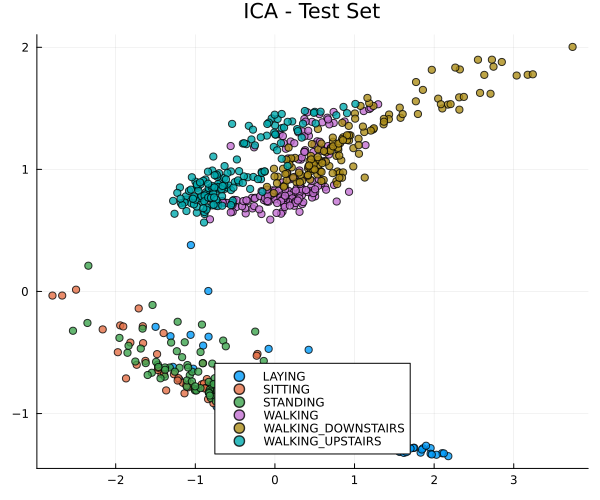

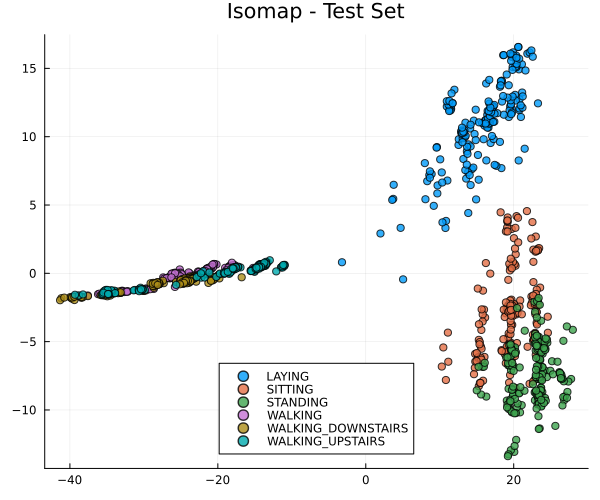

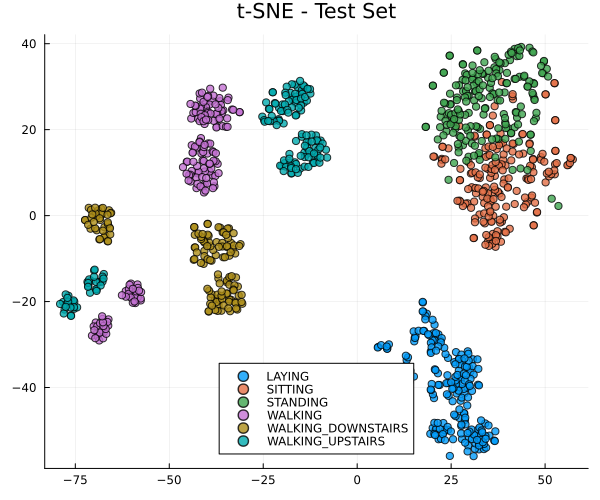

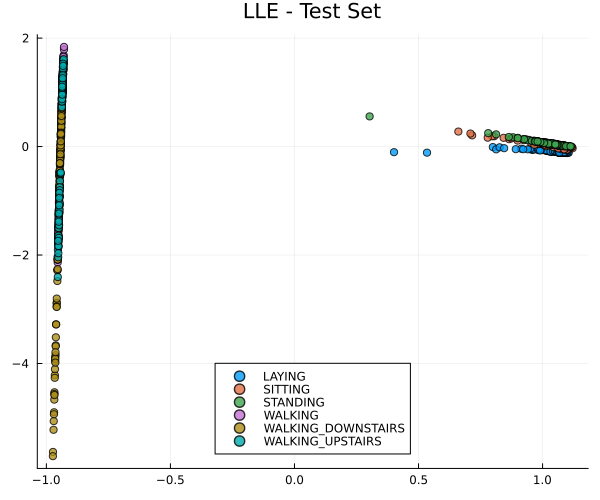

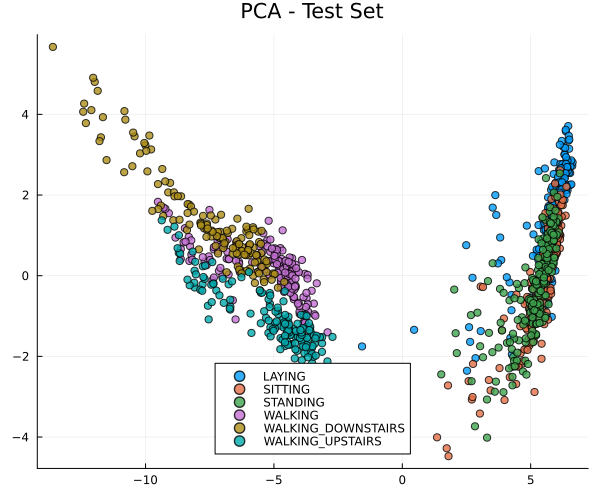

TypeError: TypeError: in keyword argument regcoef, expected Float32, got a value of type Float64

In [ ]:
using Plots
gr()

include("LLE.jl")
include("TSNE.jl")
include("ISOMAP.jl")

function plot_and_save(;x, y, targets, title_str)

    target_strings = string.(vec(targets))
    
    p = scatter(x, y, 
                group=target_strings, 
                title="$title_str - Test Set", 
                legend=:bottom, 
                markersize=4, 
                alpha=0.8,
                size=(600,500))

    display(p)

    filename = lowercase(replace(title_str, " " => "_")) * "_test.png"
    fullpath = joinpath("visualizacion", filename)
    savefig(p, fullpath)
end

# # 1. t-SNE
# tsne_test = applyTSNE(testData; perplexity=30.0)
# plot_and_save(tsne_test, testTargets, "t-SNE")

# # 2. Isomap
# isomap_test, test_comp = applyIsomap(testData; n_neighbors=20)
# println("Isomap: $(length(test_comp))/$(size(testData,1)) muestras de test")
# plot_and_save(isomap_test, testTargets[test_comp,:], "Isomap")

# # 3. LLE
# lle_test, test_comp = applyLLE(testData; n_neighbors=20)
# println("LLE: $(length(test_comp))/$(size(testData,1)) muestras de test")
# plot_and_save(lle_test, testTargets[test_comp,:], "LLE")
PCA = @load PCA pkg=MultivariateStats verbosity = 0
ICA = @load ICA pkg=MultivariateStats verbosity = 0
LDA = @load LDA pkg=MultivariateStats verbosity = 0

reducers = Dict(
    "PCA" => PCA(maxoutdim=2),
    "ICA" => ICA(outdim=2),
    # "LDA" => LDA(outdim=2),
    "Isomap" => Isomap(d = 2),
    "t-SNE" => TSNE(d = 2),
    "LLE" => LLE(k = 50, d = 2),
)


y_train = categorical(findfirst.(x -> x==1, eachrow(trainTargets)))

for (name, model) in reducers
    if MLJModelInterface.is_supervised(model)
        out, _, _ = fit(model, 0, trainData, y_train)
    else
        out, _, _ = fit(model, 0, trainData)
    end
    transformed = transform(model, out, testData) 

    mat = (transformed isa AbstractMatrix) ? transformed : MLJModelInterface.matrix(transformed)

    plot_and_save(x =vec(mat[:, 1]), y = vec(mat[:, 2]), targets = testLabels, title_str = name)
end

# 6 idk

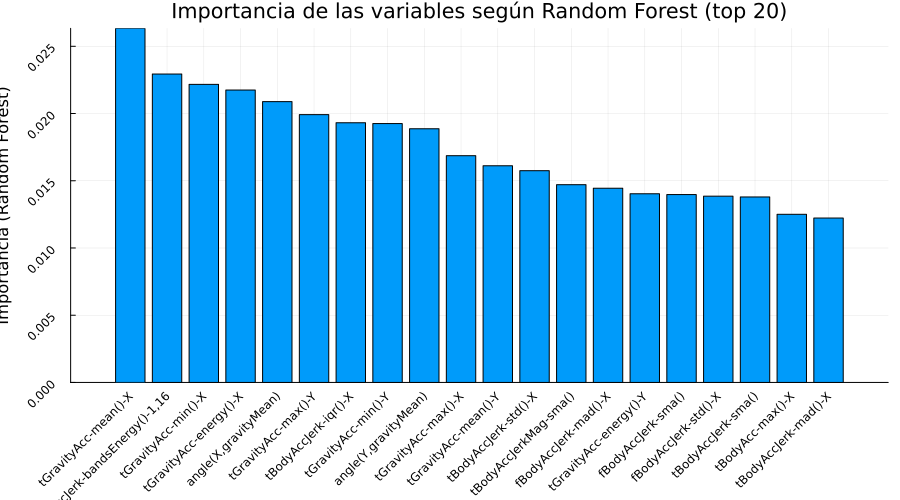

┌ Warning: The number and/or types of data arguments do not match what the specified model
│ supports. Suppress this type check by specifying `scitype_check_level=0`.
│ 
│ Run `@doc DecisionTree.RandomForestClassifier` to learn more about your model's requirements.
│ 
│ Commonly, but non exclusively, supervised models are constructed using the syntax
│ `machine(model, X, y)` or `machine(model, X, y, w)` while most other models are
│ constructed with `machine(model, X)`.  Here `X` are features, `y` a target, and `w`
│ sample or class weights.
│ 
│ In general, data in `machine(model, data...)` is expected to satisfy
│ 
│     scitype(data) <: MLJ.fit_data_scitype(model)
│ 
│ In the present case:
│ 
│ scitype(data) = Tuple{Table{Union{AbstractVector{Union{Missing, Continuous}}, AbstractVector{Continuous}}}, AbstractVector{Multiclass{6}}}
│ 
│ fit_data_scitype(model) = Tuple{Table{<:Union{AbstractVector{<:Continuous}, AbstractVector{<:Count}, AbstractVector{<:OrderedFactor}}}, AbstractVecto

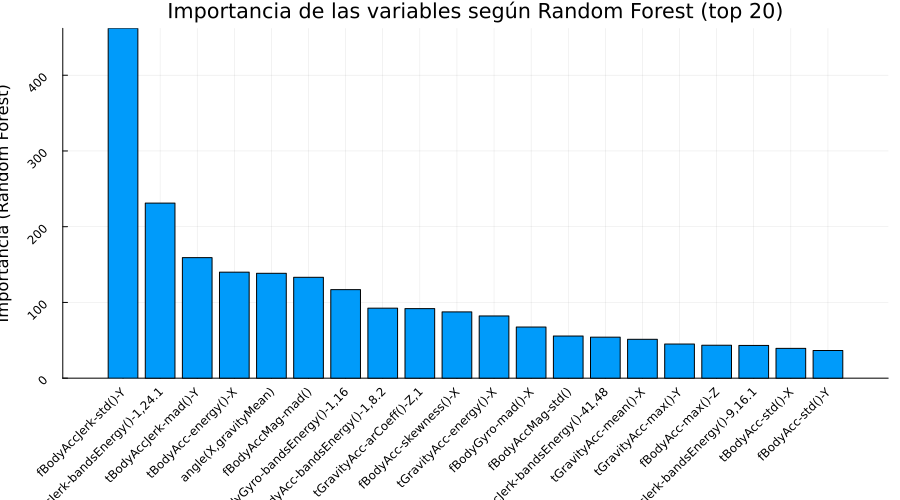

In [53]:
using MLJ
using DataFrames
using StatsBase
using Plots

function plot_feature_importance(model, data, targets)
    rf_mach = machine(model, data, y_train)
    fit!(rf_mach, verbosity=0)


    rf_importances = feature_importances(rf_mach)  # Vector con una importancia por columna

    # Asociar cada importancia con el nombre de la variable
    feature_names = names(data)

    rf_imp_df = DataFrame(
        feature = [string(name) for (name, value) in rf_importances],
        importance = [value for (name, value) in rf_importances],
    )

    # Ordenar de mayor a menor importancia
    sort!(rf_imp_df, :importance, rev=true)

    # (Opcional) Quedarse con las 20 variables más importantes para visualizar
    topK = 20
    rf_imp_top = rf_imp_df[1:min(topK, nrow(rf_imp_df)), :]

    # Gráfico de barras ordenado (IMPORTANTE PARA LA RÚBRICA)
    display(bar(
        rf_imp_top.feature,
        rf_imp_top.importance,
        legend=false,
        xticks=:all, # si hay muchos nombres, ocultas etiquetas del eje x y las comentas en la memoria
        xlabel="Variables",
        ylabel="Importancia (Random Forest)",
        title="Importancia de las variables según Random Forest (top $(topK))",
        size=(900, 500),
        rotation=45,
    ))
end


RandomForestClassifier = @load RandomForestClassifier pkg=DecisionTree verbosity = 0
XGBoostClassifier = @load XGBoostClassifier pkg=XGBoost verbosity = 0
# Modelo con los hiperparámetros que pide el enunciado
rf_model = RandomForestClassifier(n_trees = 500, max_depth = 10)
xgBoost = XGBoostClassifier() 
y_train = categorical(findfirst.(x -> x==1, eachrow(trainTargets)))
# Entrenamos el modelo (usa tus propios Xtrain_df, ytrain)
data = dataset[trainIndices,:]

plot_feature_importance(rf_model, data, y_train)
plot_feature_importance(xgBoost, data, y_train)